# Trend Ratio & Variance Contribution Ratio

## Daily vs. Weekly Sampled Volatility Measurement

**The problem:** A stock grinds up 25% over a month. Daily realized vol reads 45% annualized — benign. But implied vol prices 55%. Who's right?

The daily estimator is missing the trend because no single daily return is large, even though the cumulative displacement is enormous. This is the frog-in-boiling-water problem applied to vol measurement.

This notebook constructs two measures that decompose this phenomenon:

- **Trend Ratio (TR)** = RV20\_weekly / RV20\_daily — when TR > 1, the market has been trending faster than its daily noise would suggest
- **Variance Contribution Ratio (VCR20)** = max(r²) / sum(r²) over 20 daily returns — isolates whether elevated TR is driven by a grinding trend (low VCR) or a single spike day (high VCR)

### The 2×2 Framework

| | Low VCR (no single spike) | High VCR (one day dominates) |
|---|---|---|
| **TR > 1 (trending)** | Grinding Trend — frog is boiling slowly | Single Spike — event-driven |
| **TR < 1 (choppy)** | Normal — balanced daily noise | Spike was mean-reverting |

### Research Questions

1. Does TR systematically predict forward realized volatility?
2. Does VCR interact with the TR signal?
3. After a grinding trend (high TR, low VCR), does subsequent VCR *explode*? (Momentum crash hypothesis)
4. Is implied vol a superior estimator when it diverges from daily RV during grinding trends?

---


## 1. Configuration

**Edit this cell to customize the analysis.** Change the ticker universe, date range, or rolling window parameters.


In [17]:
# ======================================================================
#  CONFIGURATION — edit these to customize the analysis
# ======================================================================

# -- Ticker Universe ---------------------------------------------------
TICKERS = [
    # US Broad Equity
    'SPY', 'RSP', 'QQQ', 'IWM', 'VTI',
    # US Sectors
    'XLF', 'XLI', 'XLP', 'XLU', 'XLV', 'XLY', 'XLE', 'XBI', 'XHB', 'XRT', 'SMH',
    # International Equity
    'EEM', 'EFA', 'EWJ', 'FEZ', 'ASHR', 'FXI', 'EWY',
    # Fixed Income
    'TLT', 'IEF', 'HYG',
    # Real Estate
    'IYR', 'VNQ',
    # Commodities
    'GLD', 'SLV', 'GDX', 'USO', 'UNG',
    # Currencies
    'FXE', 'FXY',
]

# -- Date Range --------------------------------------------------------
START_DATE = '2015-01-01'
END_DATE   = None  # None = latest available

# -- Rolling Window Parameters -----------------------------------------
WINDOW       = 20    # Rolling window in trading days
WEEKLY_FREQ  = 5     # Sub-sampling frequency for weekly returns

# -- Annualization -----------------------------------------------------
ANN_DAILY  = 252
ANN_WEEKLY = 52

# -- Asset Class Labels ------------------------------------------------
ASSET_CLASS = {
    'SPY': 'US Equity',  'RSP': 'US Equity',  'QQQ': 'US Equity',
    'IWM': 'US Equity',  'VTI': 'US Equity',
    'XLF': 'Sector',     'XLI': 'Sector',     'XLP': 'Sector',
    'XLU': 'Sector',     'XLV': 'Sector',     'XLY': 'Sector',
    'XLE': 'Sector',     'XBI': 'Sector',     'XHB': 'Sector',
    'XRT': 'Sector',     'SMH': 'Sector',
    'EEM': 'Intl Equity', 'EFA': 'Intl Equity', 'EWJ': 'Intl Equity',
    'FEZ': 'Intl Equity', 'ASHR': 'Intl Equity', 'FXI': 'Intl Equity',
    'EWY': 'Intl Equity',
    'TLT': 'Fixed Income', 'IEF': 'Fixed Income', 'HYG': 'Fixed Income',
    'IYR': 'Real Estate',  'VNQ': 'Real Estate',
    'GLD': 'Commodity',  'SLV': 'Commodity',  'GDX': 'Commodity',
    'USO': 'Commodity',  'UNG': 'Commodity',
    'FXE': 'Currency',   'FXY': 'Currency',
}

print(f"Universe: {len(TICKERS)} tickers")
print(f"Date range: {START_DATE} to {END_DATE or 'latest'}")
print(f"Rolling window: {WINDOW} days, weekly sub-sample every {WEEKLY_FREQ} days")


Universe: 35 tickers
Date range: 2015-01-01 to latest
Rolling window: 20 days, weekly sub-sample every 5 days


## 2. Setup

In [18]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.figsize': (14, 6),
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

COLORS = {
    'primary': '#00C4E7',
    'secondary': '#F6852B',
    'accent': '#182B40',
    'neutral': '#5A5A5A',
    'bg': '#F6F4EE',
    'green': '#6DF2A1',
    'gold': '#F7C940',
    'pink': '#EC3586',
}

REGIME_COLORS = {
    'Grinding Trend': '#00C4E7',
    'Spike Trend':    '#EC3586',
    'Choppy Grind':   '#5A5A5A',
    'Spike Revert':   '#F7C940',
}


## 3. Fetch Price Data

Downloads adjusted close prices for all tickers. This is the only external data dependency.


In [19]:
def fetch_prices(tickers, start, end=None):
    """Download adjusted close prices via yfinance."""
    print(f"Fetching {len(tickers)} tickers from Yahoo Finance...")
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=True)
    
    if isinstance(raw.columns, pd.MultiIndex):
        prices = raw['Close']
    else:
        prices = raw[['Close']]
        prices.columns = tickers
    
    failed = [t for t in tickers if t not in prices.columns or prices[t].isna().all()]
    if failed:
        print(f"Warning: failed to fetch: {failed}")
        prices = prices.drop(columns=failed, errors='ignore')
    
    prices = prices.dropna(how='all')
    print(f"Fetched {prices.shape[1]} tickers, {prices.shape[0]} trading days")
    print(f"  {prices.index[0].date()} to {prices.index[-1].date()}")
    return prices

prices = fetch_prices(TICKERS, START_DATE, END_DATE)


Fetching 35 tickers from Yahoo Finance...


[*********************100%***********************]  35 of 35 completed

Fetched 35 tickers, 2818 trading days
  2015-01-02 to 2026-03-18


## 4. Variable Construction

All variables computed from close-to-close log returns over a rolling window.

| Variable | Formula | Annualization |
|---|---|---|
| RV20\_daily | `sqrt(sum(r_i²) / N)` over N daily log returns | `× sqrt(252)` |
| RV20\_weekly | `sqrt(sum(R_j²) / K)` over K weekly log returns from same window | `× sqrt(52)` |
| TR | `RV20_weekly / RV20_daily` | dimensionless |
| VCR20 | `max(r_i²) / sum(r_i²)` | percentage |

Zero-mean estimator (dividing by N, not N-1) is deliberate: it measures total quadratic variation including drift.


In [54]:
def compute_panel(prices, window=WINDOW, weekly_freq=WEEKLY_FREQ,
                   ann_daily=ANN_DAILY, ann_weekly=ANN_WEEKLY):
    """
    Compute RV20_daily, RV20_weekly, TR, and VCR20 from close prices.
    """
    n_weekly = window // weekly_freq
    all_rows = []

    for ticker in prices.columns:
        px = prices[ticker].dropna()
        if len(px) < window + 1:
            print(f"  {ticker}: insufficient data, skipping")
            continue

        close_arr = px.values
        log_ret = np.log(px / px.shift(1)).dropna()
        ret_arr = log_ret.values
        ret_dates = log_ret.index

        for i in range(window, len(ret_arr)):
            daily_rets = ret_arr[i - window : i]

            # RV20 daily (annualized %)
            rv_daily = np.sqrt(np.sum(daily_rets**2) / window) * np.sqrt(ann_daily) * 100

            # Weekly returns from same window
            weekly_closes_idx = list(range(i - window, i + 1, weekly_freq))
            if len(weekly_closes_idx) < n_weekly + 1:
                continue
            weekly_closes = close_arr[weekly_closes_idx]
            weekly_rets = np.log(weekly_closes[1:] / weekly_closes[:-1])

            # RV20 weekly (annualized %)
            rv_weekly = np.sqrt(np.sum(weekly_rets**2) / n_weekly) * np.sqrt(ann_weekly) * 100

            tr = rv_weekly / rv_daily if rv_daily > 0 else np.nan

            sum_sq = np.sum(daily_rets**2)
            vcr = (np.max(daily_rets**2) / sum_sq * 100) if sum_sq > 0 else np.nan

            all_rows.append({
                'ticker': ticker, 'date': ret_dates[i],
                'rv20_daily': rv_daily, 'rv20_weekly': rv_weekly,
                'TR': tr, 'vcr20': vcr,
            })

    panel = pd.DataFrame(all_rows)
    panel['date'] = pd.to_datetime(panel['date'])
    return panel

print("Computing rolling volatility measures...")
panel = compute_panel(prices)
print(f"\nPanel: {panel.shape[0]:,} observations")
print(f"  {panel.ticker.nunique()} tickers x ~{panel.groupby('ticker').size().median():.0f} days each")
print(f"  {panel.date.min().date()} to {panel.date.max().date()}")


Computing rolling volatility measures...

Panel: 97,895 observations
  35 tickers x ~2797 days each
  2015-02-03 to 2026-03-18


## 5. Data Validation

In [33]:
print("Missing values:")
print(panel[['rv20_daily', 'rv20_weekly', 'TR', 'vcr20']].isnull().sum().to_string())
print(f"\nInf in TR: {np.isinf(panel['TR']).sum()}")
print(f"\nRanges:")
print(f"  RV20 daily:  [{panel.rv20_daily.min():.1f}%, {panel.rv20_daily.max():.1f}%]  med = {panel.rv20_daily.median():.1f}%")
print(f"  RV20 weekly: [{panel.rv20_weekly.min():.1f}%, {panel.rv20_weekly.max():.1f}%]  med = {panel.rv20_weekly.median():.1f}%")
print(f"  TR:          [{panel.TR.min():.3f}, {panel.TR.max():.3f}]  med = {panel.TR.median():.3f}")
print(f"  VCR20:       [{panel.vcr20.min():.1f}%, {panel.vcr20.max():.1f}%]  med = {panel.vcr20.median():.1f}%")

obs = panel.groupby('ticker').size()
print(f"\nObs per ticker: min={obs.min()}, max={obs.max()}")


Missing values:
rv20_daily     0
rv20_weekly    0
TR             0
vcr20          0

Inf in TR: 0

Ranges:
  RV20 daily:  [1.5%, 176.8%]  med = 16.3%
  RV20 weekly: [0.4%, 248.1%]  med = 14.9%
  TR:          [0.022, 2.056]  med = 0.946
  VCR20:       [8.7%, 84.8%]  med = 25.2%

Obs per ticker: min=2797, max=2797


## 6. Universe Overview — Per-Ticker Distributions

In [34]:
def ticker_summary(panel):
    rows = []
    for ticker, g in panel.groupby('ticker'):
        rows.append({
            'ticker': ticker,
            'asset_class': ASSET_CLASS.get(ticker, '?'),
            'obs': len(g),
            'RV20d Med': g.rv20_daily.median(),
            'TR Med': g.TR.median(),
            'TR p05': np.percentile(g.TR, 5),
            'TR p95': np.percentile(g.TR, 95),
            'VCR Med': g.vcr20.median(),
            'VCR p05': np.percentile(g.vcr20, 5),
            'VCR p95': np.percentile(g.vcr20, 95),
        })
    return pd.DataFrame(rows).sort_values('RV20d Med').reset_index(drop=True)

ts = ticker_summary(panel)
print(ts.to_string(index=False, float_format='{:.2f}'.format))


ticker  asset_class  obs  RV20d Med  TR Med  TR p05  TR p95  VCR Med  VCR p05  VCR p95
   HYG Fixed Income 2797       5.07    0.95    0.44    1.48    25.19    15.51    49.36
   IEF Fixed Income 2797       5.48    0.94    0.46    1.45    24.28    15.39    45.02
   FXE     Currency 2797       7.04    0.94    0.46    1.45    24.40    15.66    48.45
   FXY     Currency 2797       7.88    0.94    0.46    1.45    27.98    15.99    53.27
   XLP       Sector 2797      11.20    0.90    0.47    1.40    25.40    15.62    45.51
   SPY    US Equity 2797      12.34    0.93    0.47    1.46    24.82    15.25    50.12
   RSP    US Equity 2797      12.62    0.94    0.45    1.46    25.19    15.20    45.10
   TLT Fixed Income 2797      12.65    0.92    0.46    1.42    23.37    15.66    42.15
   VTI    US Equity 2797      12.66    0.95    0.47    1.46    24.43    15.03    49.08
   XLV       Sector 2797      13.01    0.96    0.48    1.49    24.91    15.62    43.79
   EFA  Intl Equity 2797      13.11    0.95

## 7. Pooled Distributions — TR, VCR, and Their Relationship

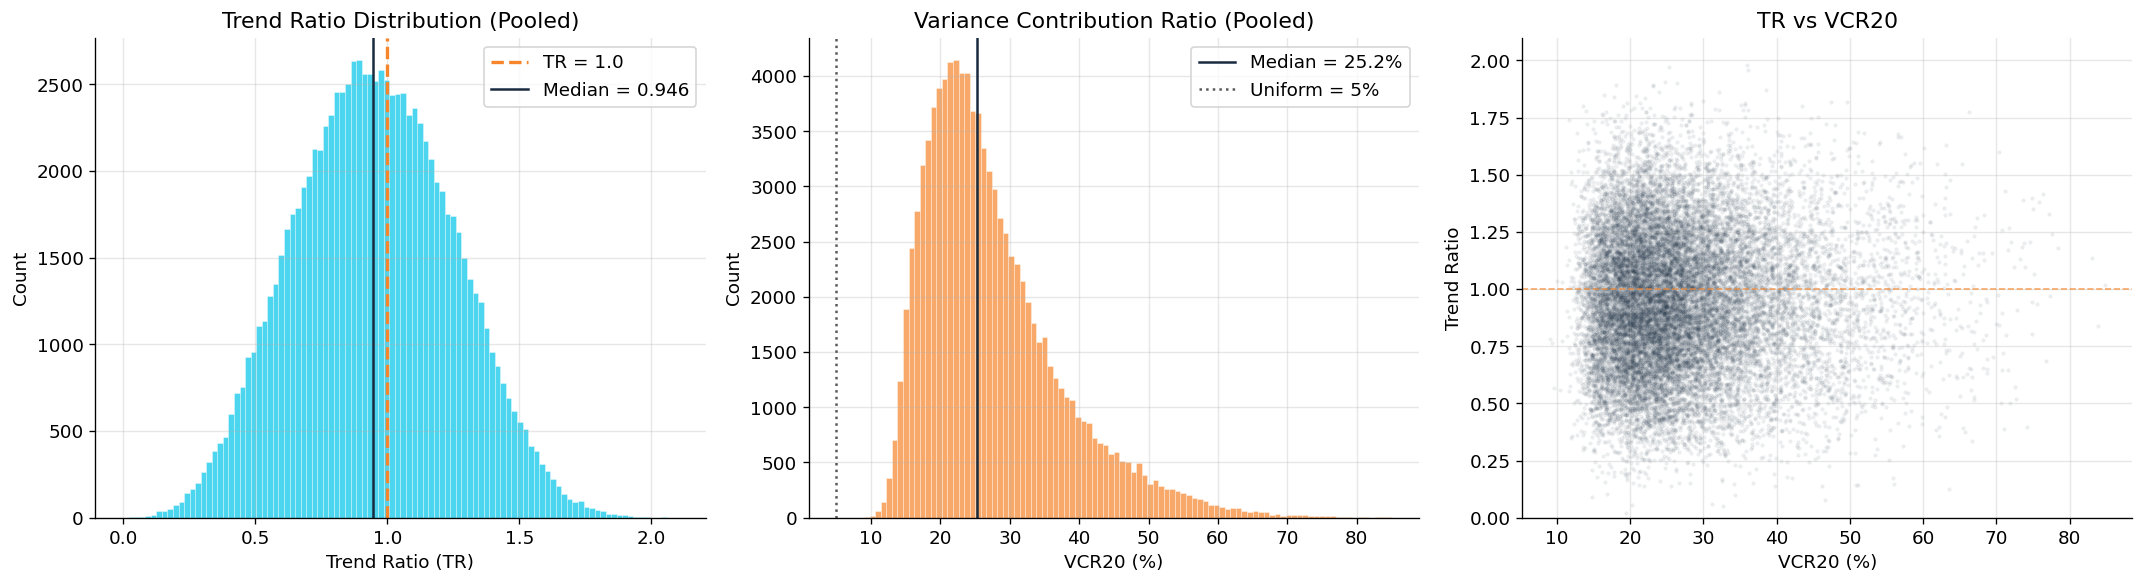


Pooled Summary:
              TR      vcr20  rv20_daily  rv20_weekly
count  97895.000  97895.000   97895.000    97895.000
mean       0.951     27.532      19.751       18.700
std        0.299     10.025      14.100       14.938
min        0.022      8.740       1.511        0.372
5%         0.465     15.564       5.679        4.360
25%        0.737     20.327      11.230        9.455
50%        0.946     25.232      16.344       14.948
75%        1.160     32.350      24.115       23.414
95%        1.449     47.659      44.319       44.628
99%        1.631     59.674      76.656       76.615
max        2.056     84.783     176.820      248.086


In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

ax = axes[0]
ax.hist(panel['TR'], bins=100, range=(0, 2.1), color=COLORS['primary'],
        alpha=0.7, edgecolor='white', linewidth=0.3)
ax.axvline(1.0, color=COLORS['secondary'], ls='--', lw=2, label='TR = 1.0')
ax.axvline(panel['TR'].median(), color=COLORS['accent'], ls='-', lw=1.5,
           label=f'Median = {panel["TR"].median():.3f}')
ax.set_xlabel('Trend Ratio (TR)')
ax.set_ylabel('Count')
ax.set_title('Trend Ratio Distribution (Pooled)')
ax.legend()

ax = axes[1]
ax.hist(panel['vcr20'], bins=100, range=(5, 85), color=COLORS['secondary'],
        alpha=0.7, edgecolor='white', linewidth=0.3)
ax.axvline(panel['vcr20'].median(), color=COLORS['accent'], ls='-', lw=1.5,
           label=f'Median = {panel["vcr20"].median():.1f}%')
ax.axvline(100 / WINDOW, color=COLORS['neutral'], ls=':', lw=1.5,
           label=f'Uniform = {100/WINDOW:.0f}%')
ax.set_xlabel('VCR20 (%)')
ax.set_ylabel('Count')
ax.set_title('Variance Contribution Ratio (Pooled)')
ax.legend()

ax = axes[2]
sample = panel.sample(n=min(20_000, len(panel)), random_state=42)
ax.scatter(sample['vcr20'], sample['TR'], alpha=0.05, s=3, color=COLORS['accent'])
ax.axhline(1.0, color=COLORS['secondary'], ls='--', lw=1, alpha=0.7)
ax.set_xlabel('VCR20 (%)')
ax.set_ylabel('Trend Ratio')
ax.set_title('TR vs VCR20')
ax.set_ylim(0, 2.1)

plt.tight_layout()
plt.show()

print("\nPooled Summary:")
print(panel[['TR', 'vcr20', 'rv20_daily', 'rv20_weekly']].describe(
    percentiles=[.05, .25, .5, .75, .95, .99]).round(3))


### Per-Ticker TR Range — Sorted by Median

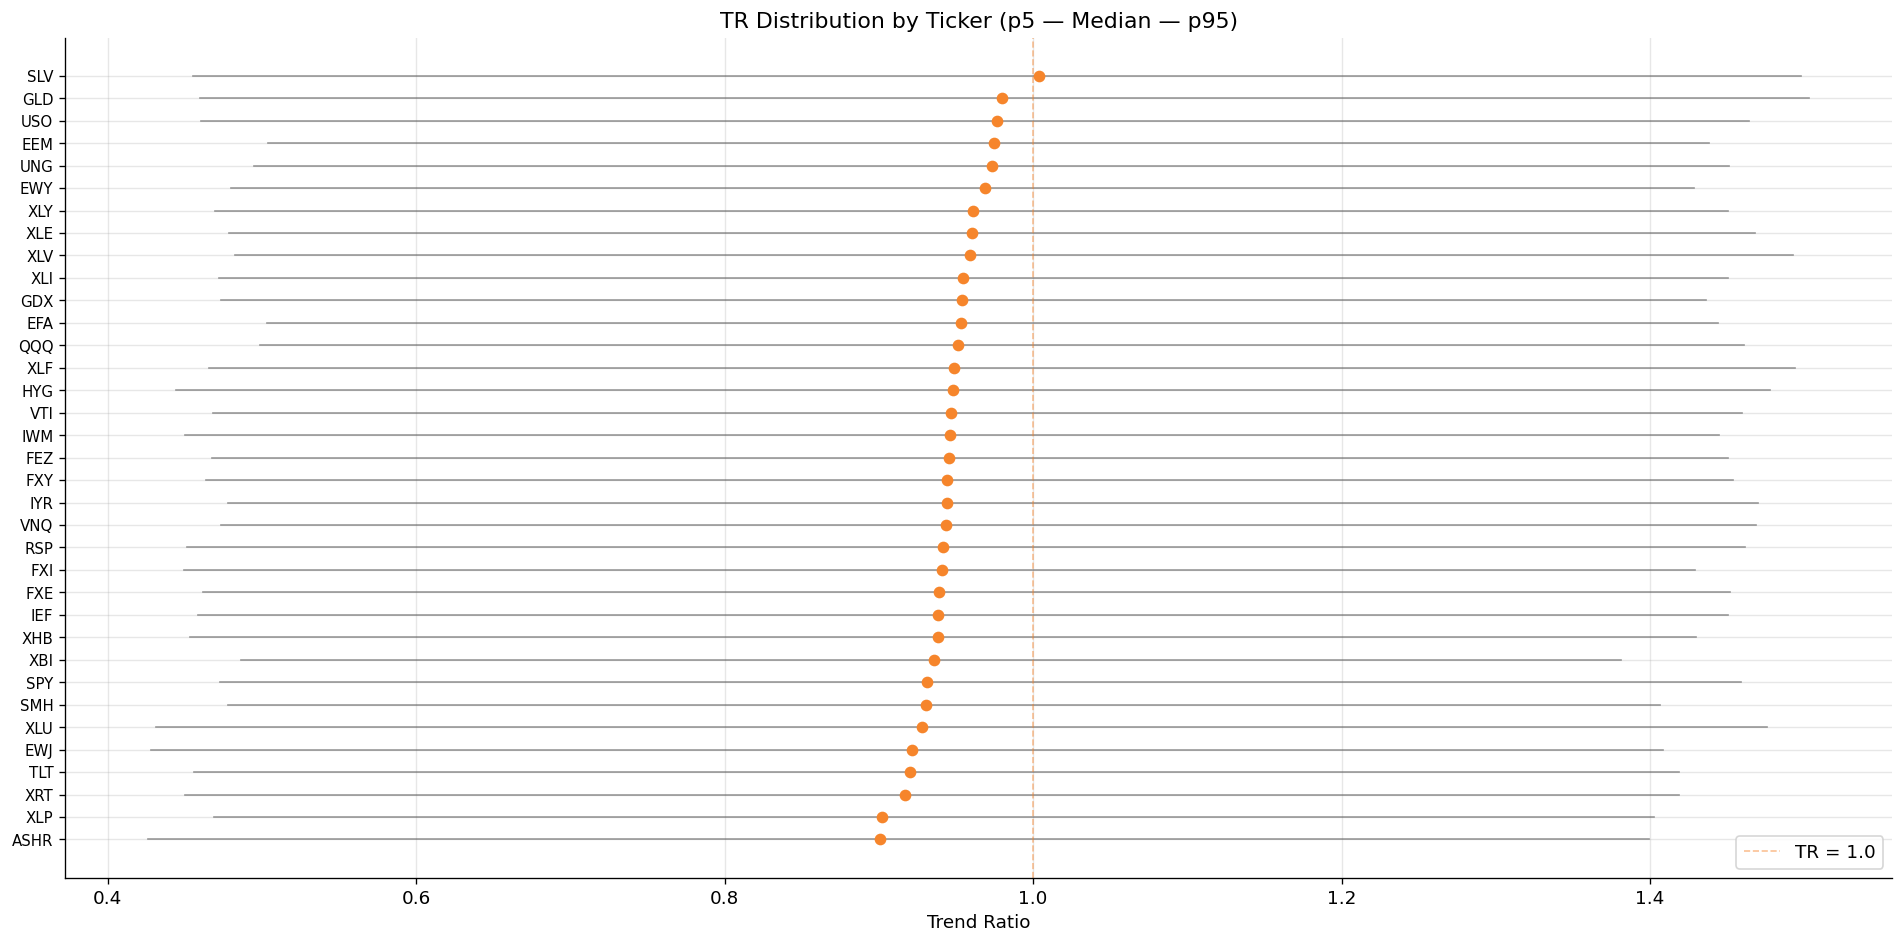

In [36]:
fig, ax = plt.subplots(figsize=(16, 8))
ts_sorted = ts.sort_values('TR Med')

for i, (_, row) in enumerate(ts_sorted.iterrows()):
    ax.plot([row['TR p05'], row['TR p95']], [i, i],
            color=COLORS['neutral'], lw=1, alpha=0.6)
    ax.plot(row['TR Med'], i, 'o', color=COLORS['secondary'], markersize=6, zorder=5)

ax.axvline(1.0, color=COLORS['secondary'], ls='--', lw=1, alpha=0.5, label='TR = 1.0')
ax.set_yticks(range(len(ts_sorted)))
ax.set_yticklabels(ts_sorted['ticker'].values, fontsize=9)
ax.set_xlabel('Trend Ratio')
ax.set_title('TR Distribution by Ticker (p5 — Median — p95)')
ax.legend()
plt.tight_layout()
plt.show()


### Per-Ticker VCR Range — Sorted by Median

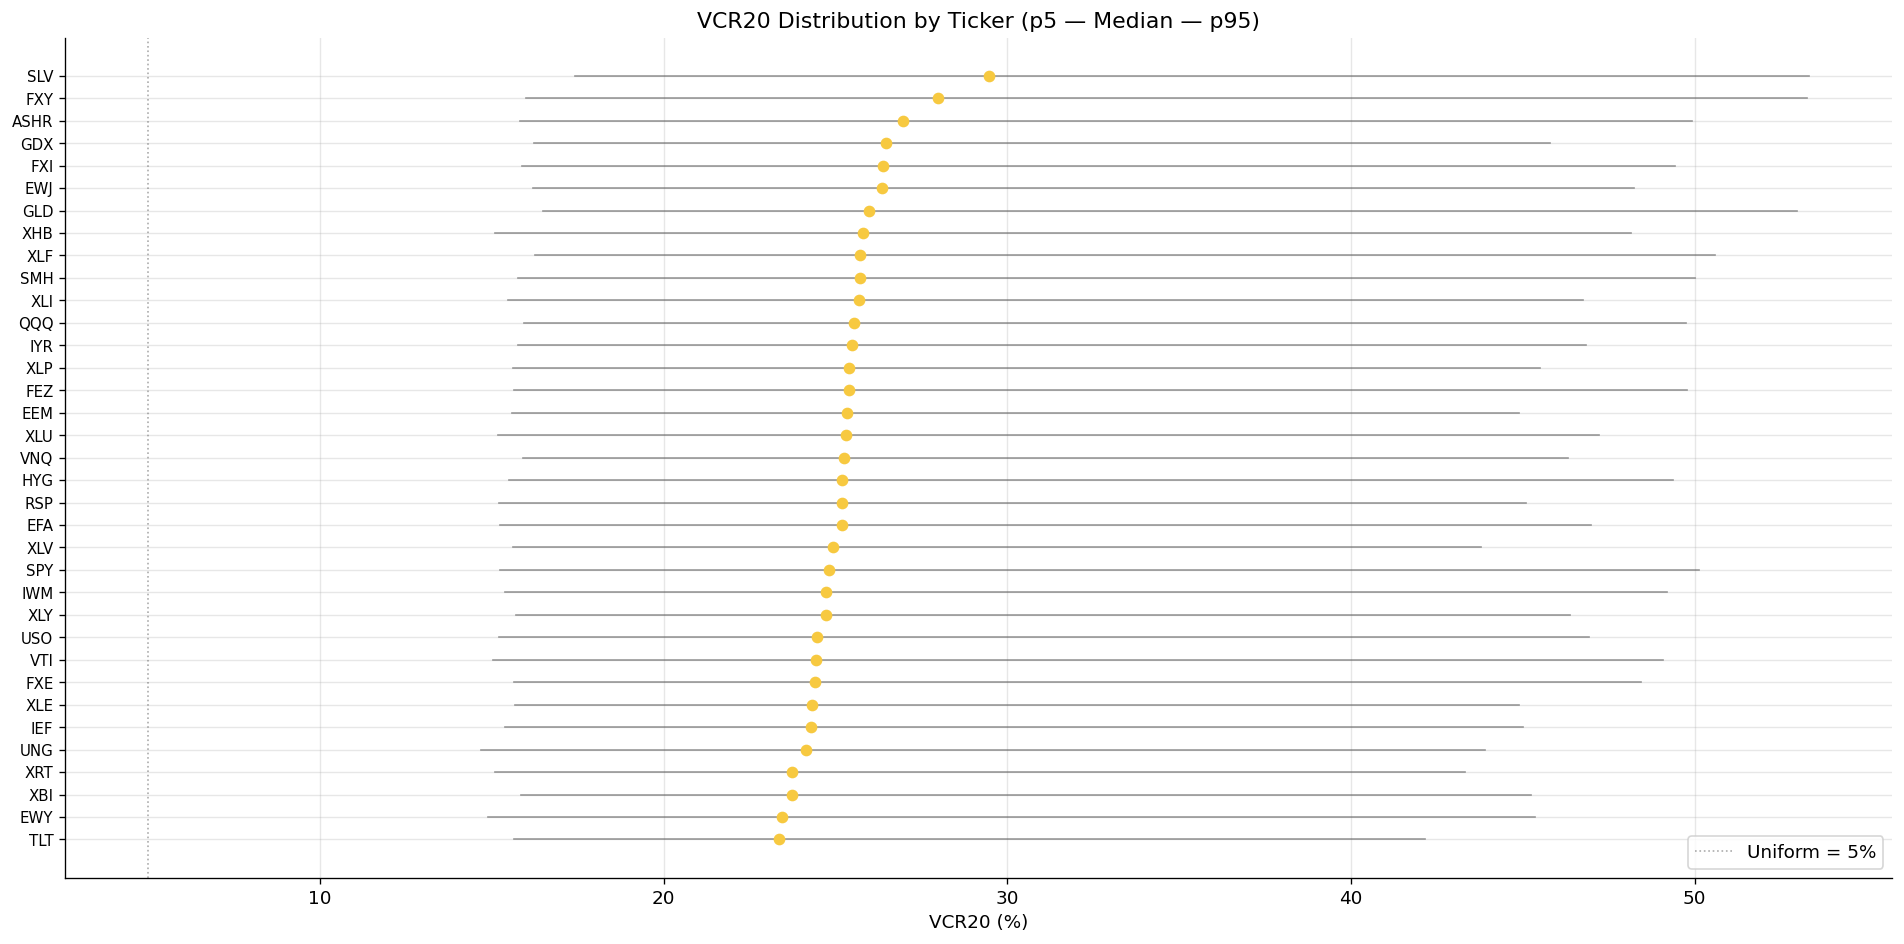

In [37]:
fig, ax = plt.subplots(figsize=(16, 8))
ts_vcr_sorted = ts.sort_values('VCR Med')

for i, (_, row) in enumerate(ts_vcr_sorted.iterrows()):
    ax.plot([row['VCR p05'], row['VCR p95']], [i, i],
            color=COLORS['neutral'], lw=1, alpha=0.6)
    ax.plot(row['VCR Med'], i, 'o', color=COLORS['gold'], markersize=6, zorder=5)

ax.axvline(100 / WINDOW, color=COLORS['neutral'], ls=':', lw=1, alpha=0.5,
           label=f'Uniform = {100/WINDOW:.0f}%')
ax.set_yticks(range(len(ts_vcr_sorted)))
ax.set_yticklabels(ts_vcr_sorted['ticker'].values, fontsize=9)
ax.set_xlabel('VCR20 (%)')
ax.set_title('VCR20 Distribution by Ticker (p5 — Median — p95)')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Time Series Case Study

Change `CASE_TICKER` to explore any ticker in the universe.


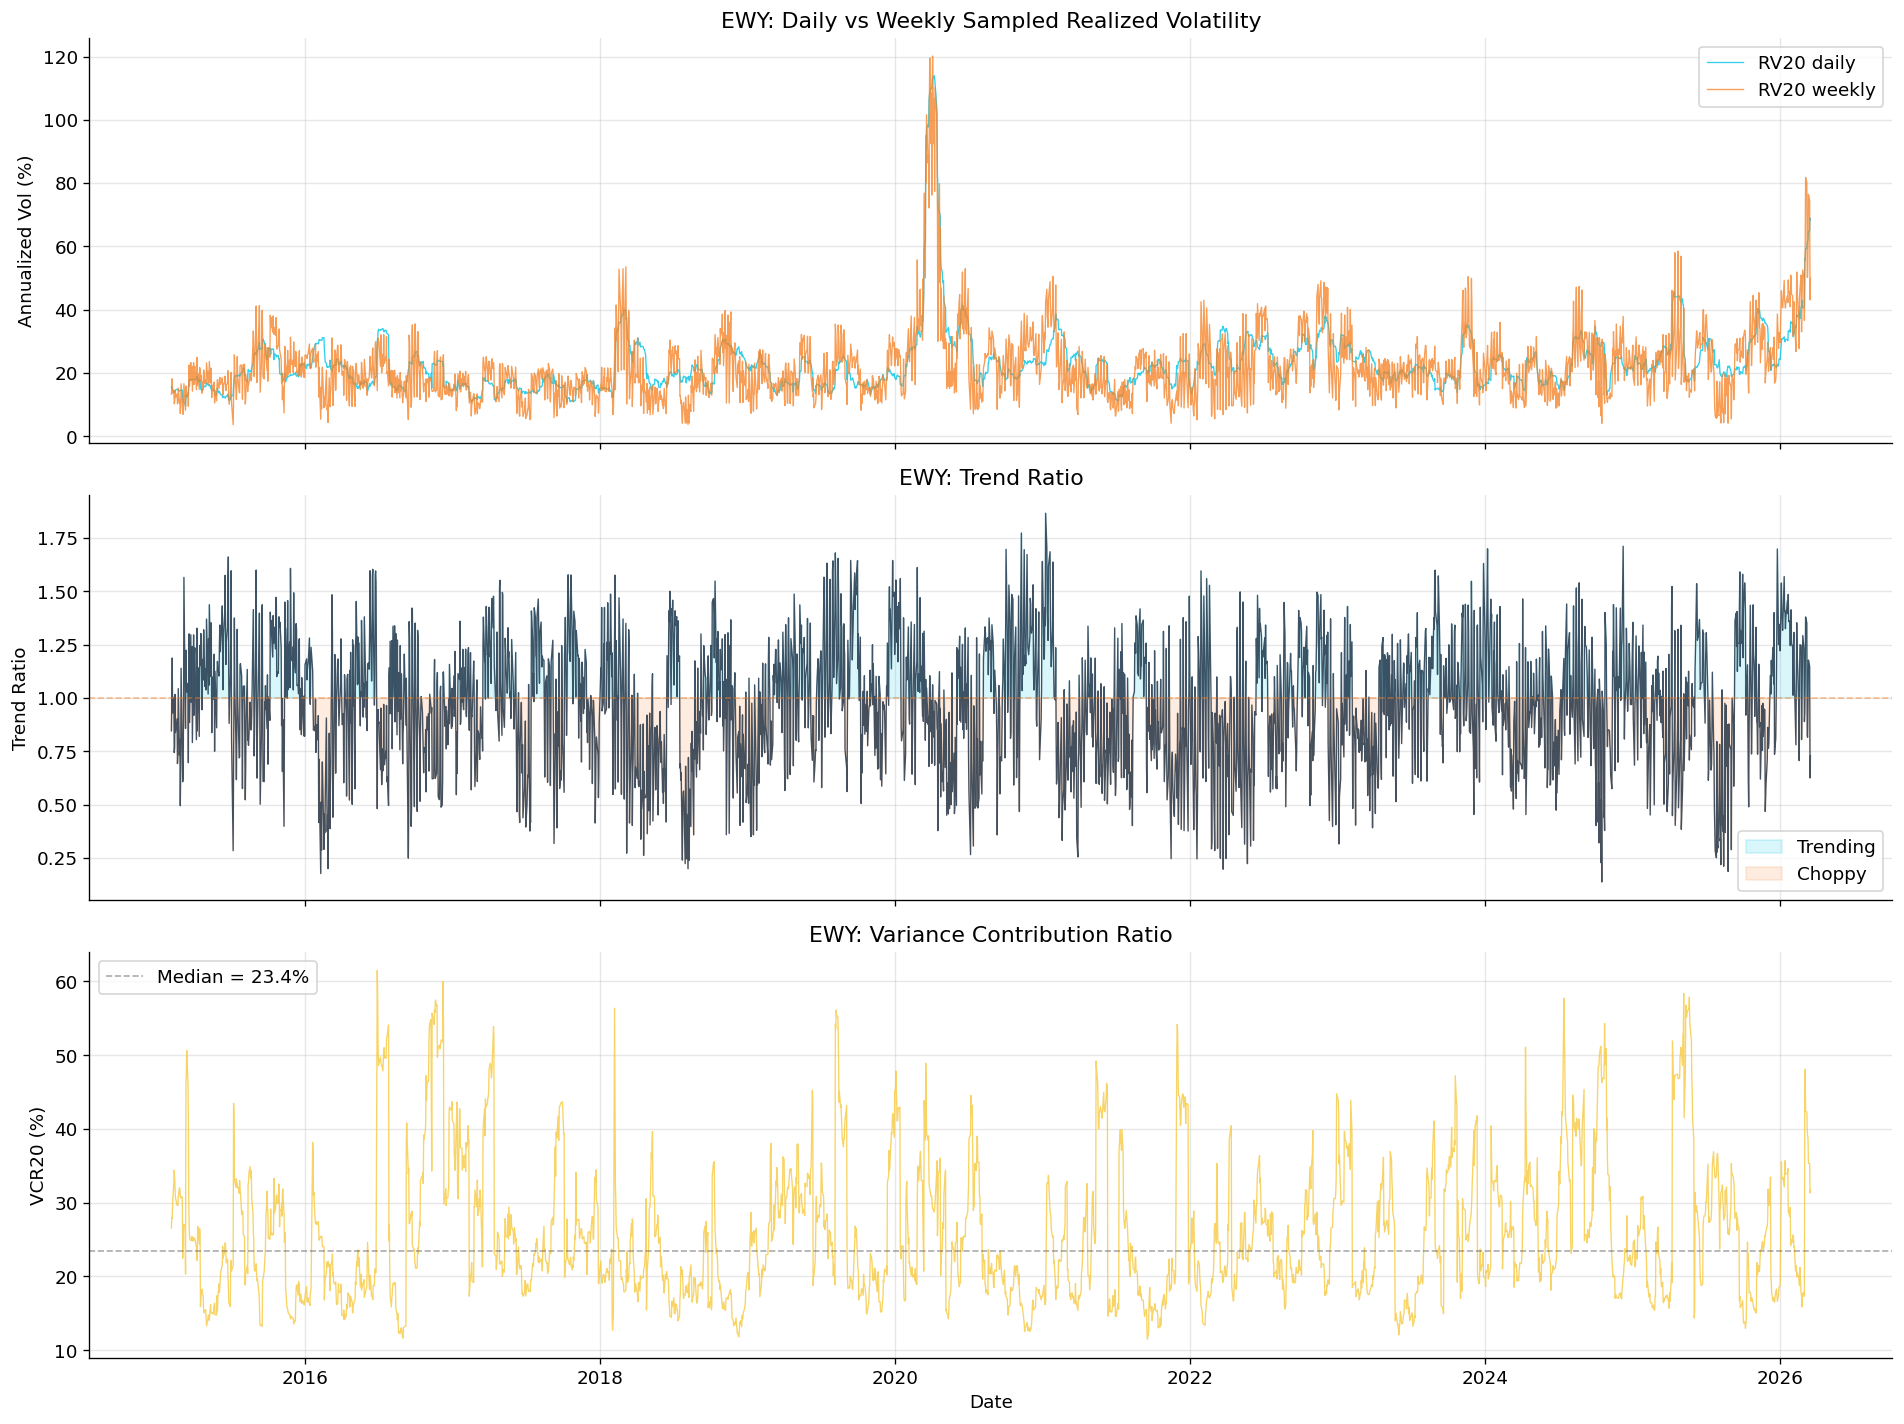

In [38]:
CASE_TICKER = 'EWY'

case = panel[panel.ticker == CASE_TICKER].sort_values('date')
if len(case) == 0:
    print(f"{CASE_TICKER} not found in panel")
else:
    fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

    ax = axes[0]
    ax.plot(case.date, case.rv20_daily, color=COLORS['primary'], alpha=0.8, lw=0.8, label='RV20 daily')
    ax.plot(case.date, case.rv20_weekly, color=COLORS['secondary'], alpha=0.8, lw=0.8, label='RV20 weekly')
    ax.set_ylabel('Annualized Vol (%)')
    ax.set_title(f'{CASE_TICKER}: Daily vs Weekly Sampled Realized Volatility')
    ax.legend()

    ax = axes[1]
    ax.plot(case.date, case.TR, color=COLORS['accent'], alpha=0.8, lw=0.8)
    ax.axhline(1.0, color=COLORS['secondary'], ls='--', lw=1, alpha=0.5)
    ax.fill_between(case.date, case.TR, 1.0, where=(case.TR > 1),
                    color=COLORS['primary'], alpha=0.15, label='Trending')
    ax.fill_between(case.date, case.TR, 1.0, where=(case.TR < 1),
                    color=COLORS['secondary'], alpha=0.15, label='Choppy')
    ax.set_ylabel('Trend Ratio')
    ax.set_title(f'{CASE_TICKER}: Trend Ratio')
    ax.legend()

    ax = axes[2]
    ax.plot(case.date, case.vcr20, color=COLORS['gold'], alpha=0.8, lw=0.8)
    ax.axhline(case.vcr20.median(), color=COLORS['neutral'], ls='--', lw=1, alpha=0.5,
               label=f'Median = {case.vcr20.median():.1f}%')
    ax.set_ylabel('VCR20 (%)')
    ax.set_xlabel('Date')
    ax.set_title(f'{CASE_TICKER}: Variance Contribution Ratio')
    ax.legend()

    plt.tight_layout()
    plt.show()


## 9. Forward Volatility Analysis — Does TR Predict Next-Period Vol Changes?

The core question: if TR is elevated today, does realized vol *increase* in the following period relative to the current period?

We compute forward 20-day RV (both daily and weekly sampled) and measure the **percent change** from current to forward: `(fwd_rv - current_rv) / current_rv`.


In [55]:
def add_forward_vars(group, ticker):
    group = group.sort_values('date').copy()
    group['ticker'] = ticker  # Preserve ticker column
    group['fwd_rv20_daily'] = group['rv20_daily'].shift(-WINDOW)
    group['fwd_rv20_weekly'] = group['rv20_weekly'].shift(-WINDOW)
    group['fwd_vcr'] = group['vcr20'].shift(-WINDOW)
    group['fwd_TR'] = group['TR'].shift(-WINDOW)
    # Percent change in RV: (forward - current) / current
    group['rv_daily_pct_chg'] = (group['fwd_rv20_daily'] - group['rv20_daily']) / group['rv20_daily'] * 100
    group['rv_weekly_pct_chg'] = (group['fwd_rv20_weekly'] - group['rv20_weekly']) / group['rv20_weekly'] * 100
    return group

panel = pd.concat([add_forward_vars(g, t) for t, g in panel.groupby('ticker')], ignore_index=True)
fwd = panel.dropna(subset=['fwd_rv20_daily']).copy()

print(f"Forward-valid observations: {len(fwd):,} "
      f"(dropped {len(panel) - len(fwd):,} from end of each series)")


Forward-valid observations: 97,195 (dropped 700 from end of each series)


### Forward RV Change by TR Quintile

For each TR quintile, we show the **mean percent change** in both daily-sampled and weekly-sampled RV from current to next period. If TR contains forward information, the high-TR quintiles should show systematically different forward RV behavior.


In [51]:
fwd['TR_q'] = pd.qcut(fwd['TR'], 5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'])

fwd_by_tr = fwd.groupby('TR_q', observed=True).agg(
    n=('TR', 'count'),
    TR_mean=('TR', 'mean'),
    cur_rv20d=('rv20_daily', 'mean'),
    fwd_rv20d=('fwd_rv20_daily', 'mean'),
    rv_daily_chg_mean=('rv_daily_pct_chg', 'mean'),
    rv_daily_chg_med=('rv_daily_pct_chg', 'median'),
    cur_rv20w=('rv20_weekly', 'mean'),
    fwd_rv20w=('fwd_rv20_weekly', 'mean'),
    rv_weekly_chg_mean=('rv_weekly_pct_chg', 'mean'),
    rv_weekly_chg_med=('rv_weekly_pct_chg', 'median'),
).round(2)

print("Forward RV Change by TR Quintile:\n")
print(fwd_by_tr.to_string())


Forward RV Change by TR Quintile:

               n  TR_mean  cur_rv20d  fwd_rv20d  rv_daily_chg_mean  rv_daily_chg_med  cur_rv20w  fwd_rv20w  rv_weekly_chg_mean  rv_weekly_chg_med
TR_q                                                                                                                                             
Q1 (Low)   19439     0.54      19.59      18.87               4.64             -3.39      10.52      18.13              104.05              70.03
Q2         19439     0.78      19.98      19.44               4.76             -3.22      15.63      18.49               28.64              15.58
Q3         19439     0.95      20.29      19.93               6.45             -2.13      19.22      18.88                7.28              -4.54
Q4         19439     1.12      19.95      20.34               9.61             -0.29      22.25      19.27               -6.26             -16.87
Q5 (High)  19439     1.38      18.78      20.13              14.83              3.41     

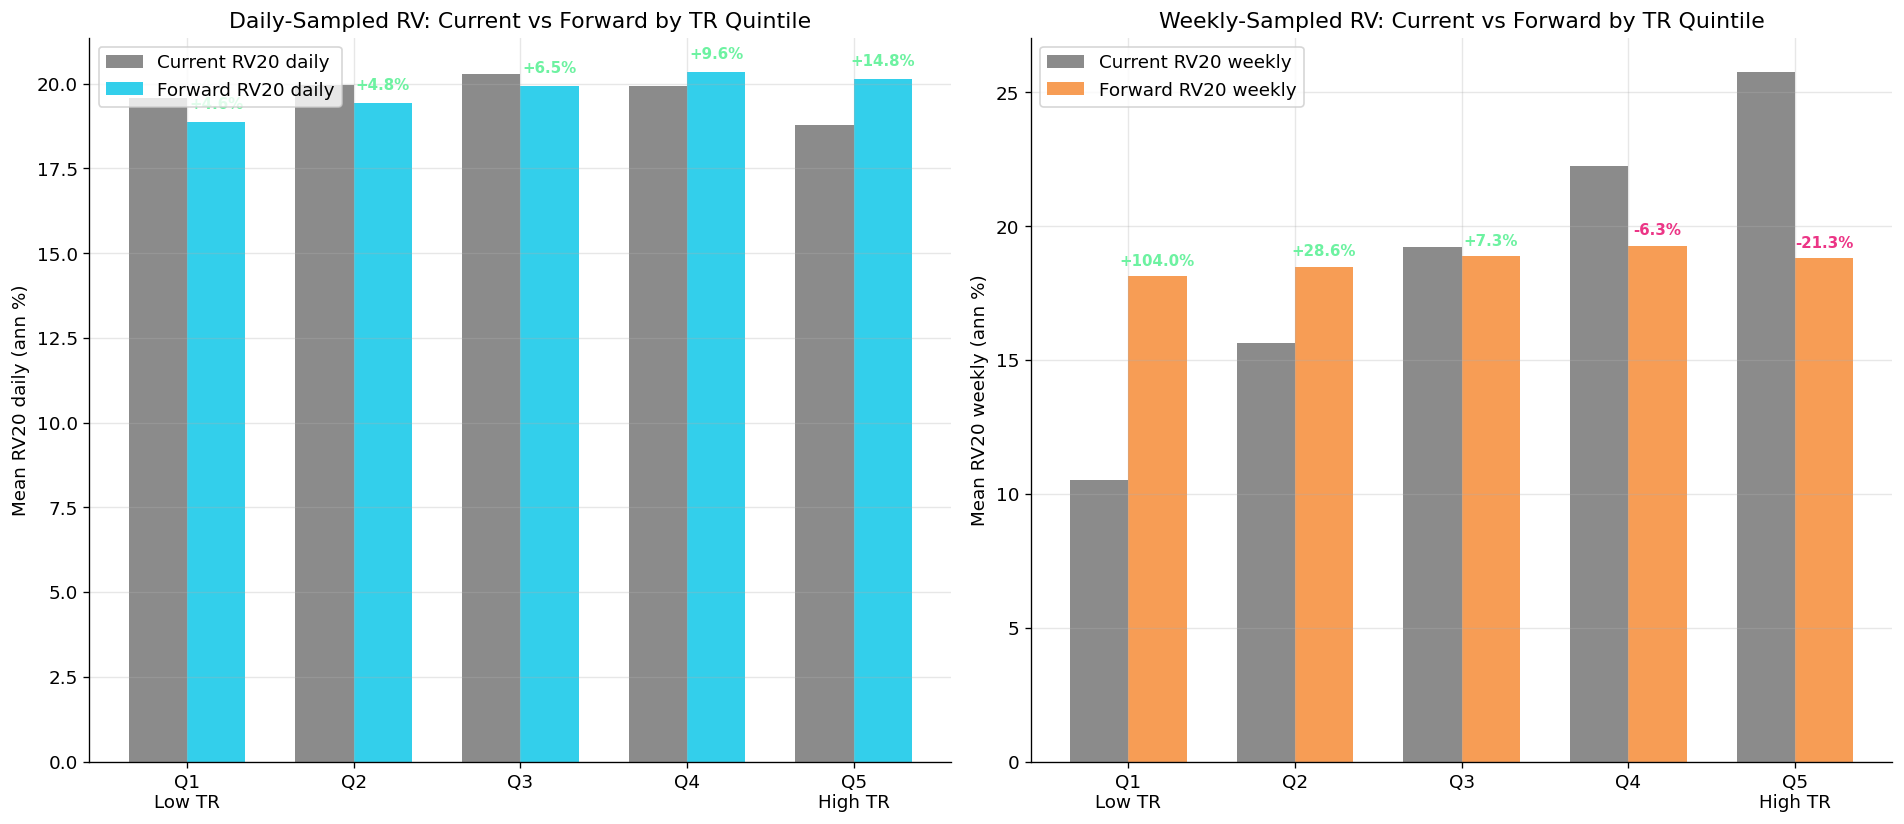

In [52]:
quintiles = ['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)']

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# -- Panel 1: Mean forward RV (daily) -- current vs forward side by side
ax = axes[0]
x = np.arange(len(quintiles))
w = 0.35
cur_vals = [fwd[fwd.TR_q == q]['rv20_daily'].mean() for q in quintiles]
fwd_vals = [fwd[fwd.TR_q == q]['fwd_rv20_daily'].mean() for q in quintiles]

bars1 = ax.bar(x - w/2, cur_vals, w, label='Current RV20 daily', color=COLORS['neutral'], alpha=0.7)
bars2 = ax.bar(x + w/2, fwd_vals, w, label='Forward RV20 daily', color=COLORS['primary'], alpha=0.8)

# Add pct change labels above the forward bars
for i, q in enumerate(quintiles):
    pct = fwd_by_tr.loc[q, 'rv_daily_chg_mean']
    color = COLORS['green'] if pct > 0 else COLORS['pink']
    ax.text(x[i] + w/2, fwd_vals[i] + 0.3, f'{pct:+.1f}%', 
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=color)

ax.set_xticks(x)
ax.set_xticklabels(['Q1\nLow TR', 'Q2', 'Q3', 'Q4', 'Q5\nHigh TR'])
ax.set_ylabel('Mean RV20 daily (ann %)')
ax.set_title('Daily-Sampled RV: Current vs Forward by TR Quintile')
ax.legend()

# -- Panel 2: Same for weekly
ax = axes[1]
cur_vals_w = [fwd[fwd.TR_q == q]['rv20_weekly'].mean() for q in quintiles]
fwd_vals_w = [fwd[fwd.TR_q == q]['fwd_rv20_weekly'].mean() for q in quintiles]

bars1 = ax.bar(x - w/2, cur_vals_w, w, label='Current RV20 weekly', color=COLORS['neutral'], alpha=0.7)
bars2 = ax.bar(x + w/2, fwd_vals_w, w, label='Forward RV20 weekly', color=COLORS['secondary'], alpha=0.8)

for i, q in enumerate(quintiles):
    pct = fwd_by_tr.loc[q, 'rv_weekly_chg_mean']
    color = COLORS['green'] if pct > 0 else COLORS['pink']
    ax.text(x[i] + w/2, fwd_vals_w[i] + 0.3, f'{pct:+.1f}%',
            ha='center', va='bottom', fontsize=9, fontweight='bold', color=color)

ax.set_xticks(x)
ax.set_xticklabels(['Q1\nLow TR', 'Q2', 'Q3', 'Q4', 'Q5\nHigh TR'])
ax.set_ylabel('Mean RV20 weekly (ann %)')
ax.set_title('Weekly-Sampled RV: Current vs Forward by TR Quintile')
ax.legend()

plt.tight_layout()
plt.show()


## 10. Regime Classification

- **TR threshold:** 1.0
- **VCR threshold:** Per-ticker median


In [56]:
# Drop existing regime columns if re-running
panel = panel.drop(columns=['vcr_median', 'regime'], errors='ignore')

vcr_medians = panel.groupby('ticker')['vcr20'].median().rename('vcr_median')
panel = panel.merge(vcr_medians, on='ticker', how='left')

def classify_regime(row):
    high_tr  = row['TR'] >= 1.0
    high_vcr = row['vcr20'] > row['vcr_median']
    if high_tr and not high_vcr:  return 'Grinding Trend'
    elif high_tr and high_vcr:    return 'Spike Trend'
    elif not high_tr and not high_vcr: return 'Choppy Grind'
    else:                         return 'Spike Revert'

panel['regime'] = panel.apply(classify_regime, axis=1)

# Propagate to fwd dataframe
fwd = fwd.drop(columns=['vcr_median', 'regime'], errors='ignore')
fwd = fwd.merge(panel[['ticker', 'date', 'vcr_median', 'regime']], on=['ticker', 'date'], how='left')

print("Regime Distribution:\n")
for r in ['Grinding Trend', 'Spike Trend', 'Choppy Grind', 'Spike Revert']:
    n = (panel.regime == r).sum()
    print(f"  {r:20s}: {n:>6,} ({n/len(panel)*100:>5.1f}%)")
print(f"  {'TOTAL':20s}: {len(panel):>6,}")


Regime Distribution:

  Grinding Trend      : 20,805 ( 21.3%)
  Spike Trend         : 21,689 ( 22.2%)
  Choppy Grind        : 28,160 ( 28.8%)
  Spike Revert        : 27,241 ( 27.8%)
  TOTAL               : 97,895


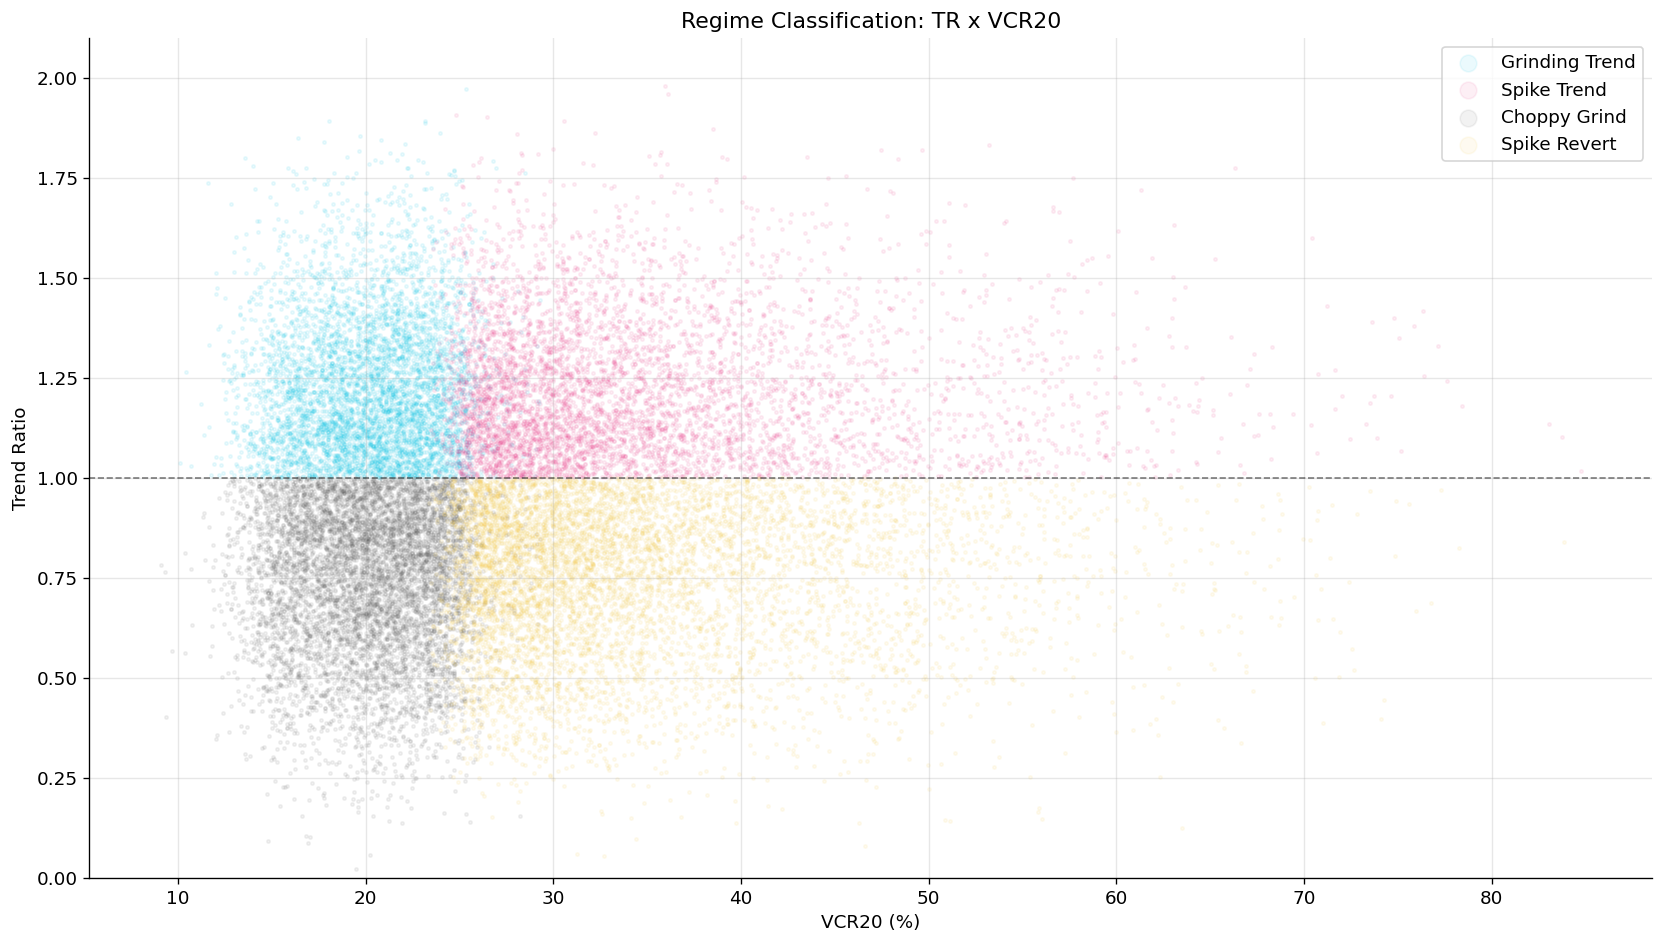

In [57]:
fig, ax = plt.subplots(figsize=(14, 8))
sample = panel.sample(n=min(25_000, len(panel)), random_state=42)
for regime, color in REGIME_COLORS.items():
    mask = sample.regime == regime
    ax.scatter(sample.loc[mask, 'vcr20'], sample.loc[mask, 'TR'],
               alpha=0.08, s=4, color=color, label=regime)
ax.axhline(1.0, color='black', ls='--', lw=1, alpha=0.5)
ax.set_xlabel('VCR20 (%)')
ax.set_ylabel('Trend Ratio')
ax.set_title('Regime Classification: TR x VCR20')
ax.set_ylim(0, 2.1)
ax.legend(loc='upper right', markerscale=5)
plt.tight_layout()
plt.show()


## 11. Regime Profiles

In [58]:
regime_order = ['Grinding Trend', 'Spike Trend', 'Choppy Grind', 'Spike Revert']

regime_summary = panel.groupby('regime').agg(
    obs=('TR', 'count'),
    TR_med=('TR', 'median'),
    VCR_med=('vcr20', 'median'),
    RV20d_med=('rv20_daily', 'median'),
    RV20w_med=('rv20_weekly', 'median'),
).reindex(regime_order).round(2)

print(regime_summary.to_string())


                  obs  TR_med  VCR_med  RV20d_med  RV20w_med
regime                                                      
Grinding Trend  20805    1.19    20.38      15.48      18.94
Spike Trend     21689    1.20    32.51      16.82      20.50
Choppy Grind    28160    0.77    20.29      16.29      11.72
Spike Revert    27241    0.77    32.23      16.72      12.16


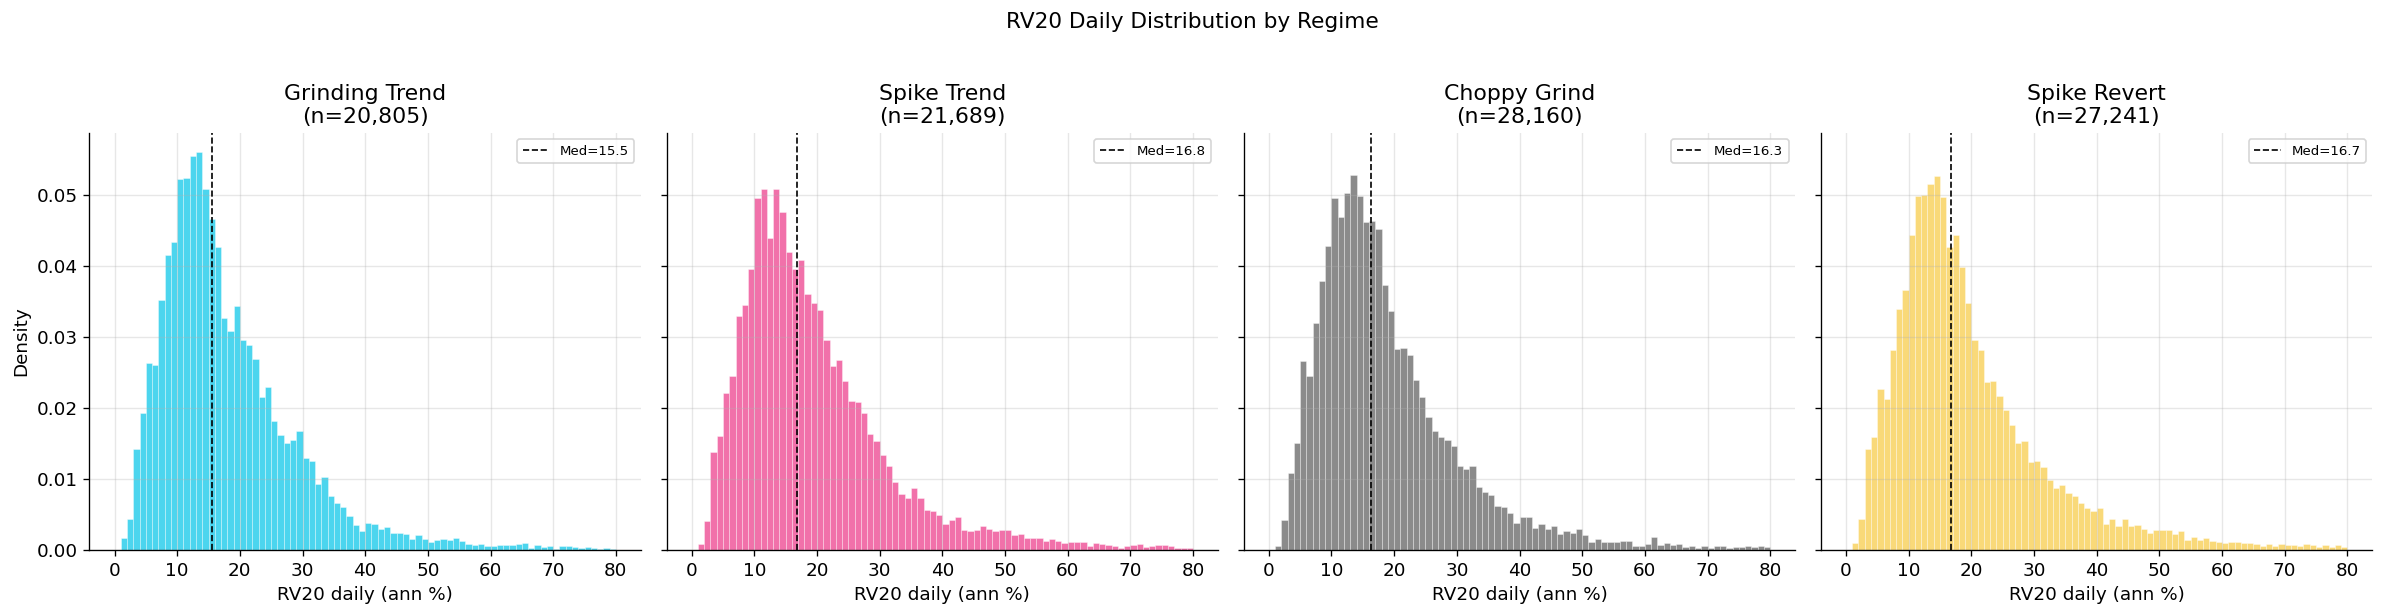

In [59]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for i, regime in enumerate(regime_order):
    ax = axes[i]
    data = panel[panel.regime == regime]['rv20_daily']
    ax.hist(data, bins=80, range=(0, 80), color=REGIME_COLORS[regime],
            alpha=0.7, edgecolor='white', linewidth=0.3, density=True)
    ax.set_title(f'{regime}\n(n={len(data):,})')
    ax.set_xlabel('RV20 daily (ann %)')
    if i == 0: ax.set_ylabel('Density')
    ax.axvline(data.median(), color='black', ls='--', lw=1, label=f'Med={data.median():.1f}')
    ax.legend(fontsize=8)
plt.suptitle('RV20 Daily Distribution by Regime', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 12. Forward RV Change — Conditioned on Top 2 TR Quintiles

For observations in Q4 and Q5 of the TR distribution (the trending regimes), what does the distribution of next-period RV changes look like?

This isolates the practical question: when you observe an elevated TR, how much should you expect realized vol to move in the next 20 days?


In [ ]:
# Ensure TR_q exists (may be lost after regime classification merge)
if 'TR_q' not in fwd.columns:
    fwd['TR_q'] = pd.qcut(fwd['TR'], 5, labels=['Q1 (Low)', 'Q2', 'Q3', 'Q4', 'Q5 (High)'])

top2 = fwd[fwd['TR_q'].isin(['Q4', 'Q5 (High)'])].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# -- Daily RV % change for Q4 and Q5
ax = axes[0]
for q, color, ls in [('Q4', COLORS['primary'], '-'), ('Q5 (High)', COLORS['accent'], '-')]:
    data = top2[top2.TR_q == q]['rv_daily_pct_chg']
    ax.hist(data, bins=100, range=(-80, 80), alpha=0.4, density=True,
            color=color, label=f'{q} (med={data.median():+.1f}%, mean={data.mean():+.1f}%)')
    ax.axvline(data.mean(), color=color, ls='--', lw=1.5)

ax.axvline(0, color='black', ls='-', lw=1)
ax.set_xlabel('RV20 Daily % Change (forward - current)')
ax.set_ylabel('Density')
ax.set_title('Forward RV20 Daily Change | Top 2 TR Quintiles')
ax.legend()

# -- Weekly RV % change for Q4 and Q5
ax = axes[1]
for q, color, ls in [('Q4', COLORS['secondary'], '-'), ('Q5 (High)', COLORS['accent'], '-')]:
    data = top2[top2.TR_q == q]['rv_weekly_pct_chg']
    ax.hist(data, bins=100, range=(-80, 80), alpha=0.4, density=True,
            color=color, label=f'{q} (med={data.median():+.1f}%, mean={data.mean():+.1f}%)')
    ax.axvline(data.mean(), color=color, ls='--', lw=1.5)

ax.axvline(0, color='black', ls='-', lw=1)
ax.set_xlabel('RV20 Weekly % Change (forward - current)')
ax.set_ylabel('Density')
ax.set_title('Forward RV20 Weekly Change | Top 2 TR Quintiles')
ax.legend()

plt.tight_layout()
plt.show()

# Summary table
print("\nSummary: Forward RV % Change for Top 2 TR Quintiles\n")
for q in ['Q4', 'Q5 (High)']:
    sub = top2[top2.TR_q == q]
    print(f"  {q}:")
    print(f"    RV daily  pct chg: mean={sub.rv_daily_pct_chg.mean():+.1f}%, med={sub.rv_daily_pct_chg.median():+.1f}%")
    print(f"    RV weekly pct chg: mean={sub.rv_weekly_pct_chg.mean():+.1f}%, med={sub.rv_weekly_pct_chg.median():+.1f}%")
    print(f"    % of obs where fwd RV daily > current: {(sub.rv_daily_pct_chg > 0).mean()*100:.1f}%")
    print(f"    % of obs where fwd RV weekly > current: {(sub.rv_weekly_pct_chg > 0).mean()*100:.1f}%")
    print()


KeyError: 'TR_q'

## 13. TR × VCR Heatmap — Forward RV Premium/Discount

Each cell shows the **median percent change** in RV20 daily from the current 20-day window to the next: `(fwd_rv - current_rv) / current_rv × 100`.

- **Positive values (green):** forward vol is *higher* than current vol — the market is getting more volatile
- **Negative values (red):** forward vol is *lower* — vol is mean-reverting down
- **The upper-right quadrant** (high TR, high VCR) is where spike-driven trends live
- **High TR, low VCR** is the grinding trend zone — does vol rise or fall after a quiet grind?


In [ ]:
fwd['TR_bin'] = pd.cut(fwd['TR'],
    bins=[0, 0.6, 0.8, 0.9, 1.0, 1.1, 1.2, 1.4, 2.1],
    labels=['<0.6', '0.6-0.8', '0.8-0.9', '0.9-1.0', '1.0-1.1', '1.1-1.2', '1.2-1.4', '>1.4'])

fwd['VCR_bin'] = pd.cut(fwd['vcr20'],
    bins=[0, 15, 20, 25, 30, 40, 50, 100],
    labels=['<15', '15-20', '20-25', '25-30', '30-40', '40-50', '>50'])

# Pivot: median % change in forward RV daily
pivot_pct = fwd.pivot_table(
    values='rv_daily_pct_chg', index='VCR_bin', columns='TR_bin', aggfunc='median'
).round(1)
counts = fwd.pivot_table(
    values='rv_daily_pct_chg', index='VCR_bin', columns='TR_bin', aggfunc='count'
)

fig, ax = plt.subplots(figsize=(15, 9))

vals = pivot_pct.values
# Center the colormap on 0
vmax = max(abs(np.nanmin(vals)), abs(np.nanmax(vals)))
im = ax.imshow(vals, cmap='RdYlGn_r', aspect='auto', vmin=-vmax, vmax=vmax)

for i in range(len(pivot_pct.index)):
    for j in range(len(pivot_pct.columns)):
        v = vals[i, j]
        n = counts.values[i, j]
        if not np.isnan(v):
            color = 'white' if abs(v) > vmax * 0.6 else 'black'
            sign = '+' if v > 0 else ''
            ax.text(j, i, f'{sign}{v:.1f}%\n(n={int(n):,})',
                    ha='center', va='center', fontsize=8, color=color)

ax.set_xticks(range(len(pivot_pct.columns)))
ax.set_xticklabels(pivot_pct.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot_pct.index)))
ax.set_yticklabels(pivot_pct.index)
ax.set_xlabel('Current TR Bin')
ax.set_ylabel('Current VCR20 Bin')
ax.set_title('Median Forward RV20 Daily % Change by Current TR x VCR20\n'
             '(positive = vol increases next period, negative = vol decreases)')
plt.colorbar(im, shrink=0.8, label='Median % Change')

plt.tight_layout()
plt.show()


## 14. Export

In [ ]:
output_path = 'etf_vol_ratio_panel.csv'
panel.to_csv(output_path, index=False)
print(f"Panel exported to {output_path}")
print(f"  {panel.shape[0]:,} rows x {panel.shape[1]} cols")
